In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("../data/raw/student-mat.csv")

# Create target
df["Academic_Risk"] = np.where(df["G3"] < 10, 1, 0)

# Features and target
X = df.drop(["G3", "Academic_Risk"], axis=1)
y = df["Academic_Risk"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split Complete")
print(X_train.shape)
print(X_test.shape)

Split Complete
(316, 32)
(79, 32)


In [5]:
# ===============================
# Preprocessing Pipeline
# ===============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns


categorical_features = X_train.select_dtypes(
    include=["object"]
).columns


print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))


# Numerical preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# Combine both

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


print("\nPreprocessing Pipeline Created Successfully!")

Numerical Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical Features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Preprocessing Pipeline Created Successfully!


C:\Users\mizba\AppData\Local\Temp\ipykernel_37256\4139933773.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [6]:
# ===============================
# Baseline Model - Dummy Classifier
# ===============================

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Create baseline pipeline

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]
)


# Train baseline

baseline_model.fit(X_train, y_train)


# Predict

y_pred = baseline_model.predict(X_test)


# Evaluation

print("Baseline Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nBaseline Precision:")
print(precision_score(y_test, y_pred, zero_division=0))

print("\nBaseline Recall:")
print(recall_score(y_test, y_pred, zero_division=0))

print("\nBaseline F1 Score:")
print(f1_score(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Accuracy:
0.6708860759493671

Baseline Precision:
0.0

Baseline Recall:
0.0

Baseline F1 Score:
0.0

Confusion Matrix:
[[53  0]
 [26  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        53
           1       0.00      0.00      0.00        26

    accuracy                           0.67        79
   macro avg       0.34      0.50      0.40        79
weighted avg       0.45      0.67      0.54        79



d:\EarlyAcademicSupport\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\EarlyAcademicSupport\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\EarlyAcademicSupport\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [7]:
# ===============================
# ML Model Comparison
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Define models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


results = {}


# Train and evaluate each model

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    }


# Display results

results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.936709,0.956522,0.846154,0.897959
Random Forest,0.911392,0.851852,0.884615,0.867925
Gradient Boosting,0.924051,0.884615,0.884615,0.884615


In [8]:
# ===============================
# Select Best Model
# ===============================

# Sort models by Recall and F1 Score

print("Models ranked by Recall:")
display(
    results_df.sort_values(
        by="Recall",
        ascending=False
    )
)


print("\nModels ranked by F1 Score:")
display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)

Models ranked by Recall:


,Accuracy,Precision,Recall,F1 Score
Random Forest,0.911392,0.851852,0.884615,0.867925
Gradient Boosting,0.924051,0.884615,0.884615,0.884615
Logistic Regression,0.936709,0.956522,0.846154,0.897959



Models ranked by F1 Score:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.936709,0.956522,0.846154,0.897959
Gradient Boosting,0.924051,0.884615,0.884615,0.884615
Random Forest,0.911392,0.851852,0.884615,0.867925


In [9]:
# ===============================
# Cross Validation
# ===============================

from sklearn.model_selection import StratifiedKFold, cross_validate


# Example: choose Random Forest
best_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scores = cross_validate(
    best_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)


print("CV Accuracy:", scores["test_accuracy"].mean())
print("CV Precision:", scores["test_precision"].mean())
print("CV Recall:", scores["test_recall"].mean())
print("CV F1:", scores["test_f1"].mean())

CV Accuracy: 0.908860759493671
CV Precision: 0.8525135783756473
CV Recall: 0.876923076923077
CV F1: 0.8612941274643402


In [10]:
# ===============================
# Final Model Training
# ===============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib
import os


# Final selected model

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)


# Train on training data

final_model.fit(
    X_train,
    y_train
)


print("Final Model Trained Successfully!")


# Create model folder

os.makedirs("../models", exist_ok=True)


# Save model

joblib.dump(
    final_model,
    "../models/student_risk_model.pkl"
)


print("Model Saved Successfully!")

Final Model Trained Successfully!
Model Saved Successfully!


In [11]:
# ===============================
# Final Model Evaluation
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test prediction

y_test_pred = final_model.predict(X_test)


# Metrics

print("Final Test Accuracy:")
print(accuracy_score(y_test, y_test_pred))


print("\nFinal Test Precision:")
print(precision_score(y_test, y_test_pred, zero_division=0))


print("\nFinal Test Recall:")
print(recall_score(y_test, y_test_pred, zero_division=0))


print("\nFinal Test F1 Score:")
print(f1_score(y_test, y_test_pred, zero_division=0))


# Confusion Matrix

print("\nConfusion Matrix:")
display(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)


# Detailed Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

Final Test Accuracy:
0.9113924050632911

Final Test Precision:
0.8518518518518519

Final Test Recall:
0.8846153846153846

Final Test F1 Score:
0.8679245283018868

Confusion Matrix:


array([[49,  4],
       [ 3, 23]])


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        53
           1       0.85      0.88      0.87        26

    accuracy                           0.91        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.91      0.91      0.91        79



In [12]:
# Check target distribution

y.value_counts()

Academic_Risk
0    265
1    130
Name: count, dtype: int64

In [14]:
type(model)


sklearn.ensemble._gb.GradientBoostingClassifier

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import joblib
import os


# Target separate karo

X = df.drop("Academic_Risk", axis=1)
y = df["Academic_Risk"]


# Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Columns identify

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns


categorical_features = X_train.select_dtypes(
    include=["object"]
).columns



# Preprocessing

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]
)



# Full pipeline

pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            GradientBoostingClassifier(
                random_state=42
            )
        )

    ]

)



# Train

pipeline.fit(
    X_train,
    y_train
)



# Save complete pipeline

os.makedirs("../models", exist_ok=True)


joblib.dump(
    pipeline,
    "../models/student_risk_model.pkl"
)


print("Complete pipeline saved successfully")

C:\Users\mizba\AppData\Local\Temp\ipykernel_37256\2075891942.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


Complete pipeline saved successfully


In [16]:
type(pipeline)

sklearn.pipeline.Pipeline

In [17]:
pred = pipeline.predict(X_test)

pd.Series(pred).value_counts()

0    53
1    26
Name: count, dtype: int64

In [18]:
prob = pipeline.predict_proba(X_test)[:,1]

prob[:10]

array([9.99971266e-01, 1.46392426e-05, 1.46392426e-05, 9.99971266e-01,
       9.99971266e-01, 1.46392426e-05, 1.46392426e-05, 1.46392426e-05,
       9.99971266e-01, 1.46392426e-05])

In [19]:
pred = pipeline.predict(X_test)

pd.Series(pred).value_counts()

0    53
1    26
Name: count, dtype: int64

In [20]:
prob = pipeline.predict_proba(X_test)[:,1]

print("Minimum:", prob.min())
print("Maximum:", prob.max())
print("Average:", prob.mean())

Minimum: 1.4639242588944726e-05
Maximum: 0.999971266364529
Average: 0.32911428867512627


In [21]:
X_test.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
383,MS,M,19,R,GT3,T,1,1,other,services,...,4,3,2,1,3,5,0,6,5,0
19,GP,M,16,U,LE3,T,4,3,health,other,...,3,1,3,1,3,5,4,8,10,10
193,GP,M,16,R,GT3,T,3,3,services,services,...,4,3,2,3,4,5,8,8,9,10
343,GP,F,17,U,GT3,A,2,2,at_home,at_home,...,3,3,1,1,2,4,0,9,8,0
92,GP,F,16,U,LE3,T,3,1,other,other,...,3,3,3,2,3,2,4,7,6,6


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import joblib
import os


# Remove G3 leakage

X = df.drop(
    ["G3", "Academic_Risk"],
    axis=1
)

y = df["Academic_Risk"]


# Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Columns

numeric_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns


categorical_features = X_train.select_dtypes(
    include=["object"]
).columns



# Preprocessor

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]

)



# Pipeline

model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )

    ]

)



# Train

model.fit(
    X_train,
    y_train
)



# Save

joblib.dump(
    model,
    "../models/student_risk_model.pkl"
)


print("New model saved without G3 leakage")

C:\Users\mizba\AppData\Local\Temp\ipykernel_37256\2221250039.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


New model saved without G3 leakage


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Prediction

y_pred = model.predict(X_test)


print("Accuracy:",
      accuracy_score(y_test,y_pred))


print("Precision:",
      precision_score(y_test,y_pred))


print("Recall:",
      recall_score(y_test,y_pred))


print("F1 Score:",
      f1_score(y_test,y_pred))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))


print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy: 0.9240506329113924
Precision: 0.8846153846153846
Recall: 0.8846153846153846
F1 Score: 0.8846153846153846

Confusion Matrix:
[[50  3]
 [ 3 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        53
           1       0.88      0.88      0.88        26

    accuracy                           0.92        79
   macro avg       0.91      0.91      0.91        79
weighted avg       0.92      0.92      0.92        79



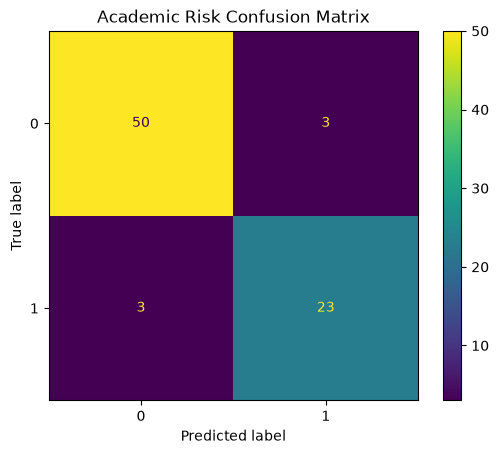

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title(
    "Academic Risk Confusion Matrix"
)

plt.show()